In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [47]:
df = pd.read_excel('/content/barley (2).xlsx')
display(df.head())


,Nutrient,Location,Agro_Ecological_Zone,SOIL_TYPE,Rep,Rate,GY,BY
0,S,Gololcha,SH3,Cambisols,1,0,4443,15333
1,S,Gololcha,SH3,Cambisols,1,10,4067,15667
2,S,Gololcha,SH3,Cambisols,1,20,3895,14333
3,S,Gololcha,SH3,Cambisols,1,30,3809,13333
4,S,Gololcha,SH3,Cambisols,1,40,3644,14000


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Nutrient              1494 non-null   object
 1   Location              1494 non-null   object
 2   Agro_Ecological_Zone  1494 non-null   object
 3   SOIL_TYPE             1494 non-null   object
 4   Rep                   1494 non-null   int64 
 5   Rate                  1494 non-null   int64 
 6   GY                    1494 non-null   object
 7   BY                    1494 non-null   object
dtypes: int64(2), object(6)
memory usage: 93.5+ KB


In [49]:
# Check for missing values
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0].sort_values(ascending=False))

,0


In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
# --- Convert string column(s) to float ---

df["GY"] = pd.to_numeric(df["GY"], errors="coerce")
df["BY"] = pd.to_numeric(df["BY"], errors="coerce")

# Optional: drop rows where conversion failed (now NaN)
df = df.dropna(subset=["GY", "BY"]).reset_index(drop=True)

print(df[["GY", "BY"]].dtypes)

GY    float64
BY    float64
dtype: object


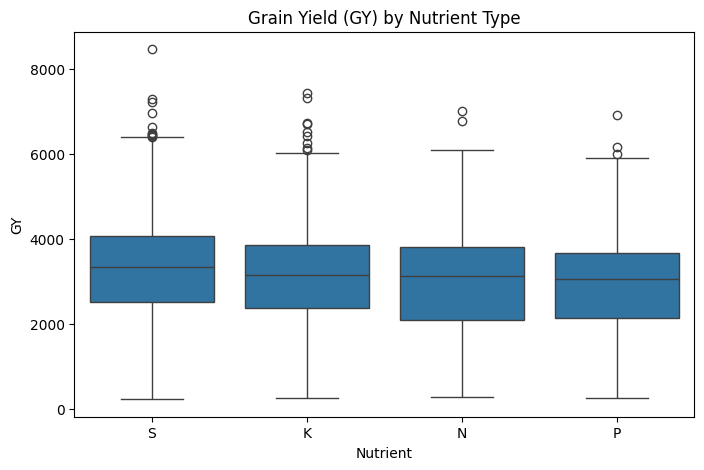

In [52]:
# 3. Boxplot of GY across Nutrient types - see which nutrient gives higher yield
plt.figure(figsize=(8, 5))
sns.boxplot(x='Nutrient', y='GY', data=df)
plt.title('Grain Yield (GY) by Nutrient Type')
plt.show()

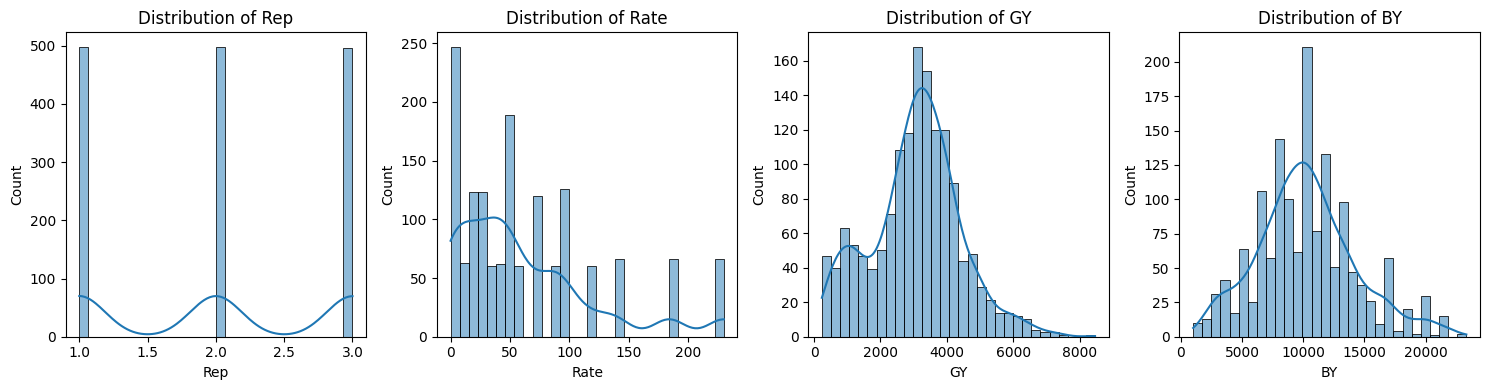

In [54]:
# 1. Histograms - distribution shape of each numeric variable
plt.figure(figsize=(15, 4))
numerical_cols = ['Rep', 'Rate', 'GY', 'BY']
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 4, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

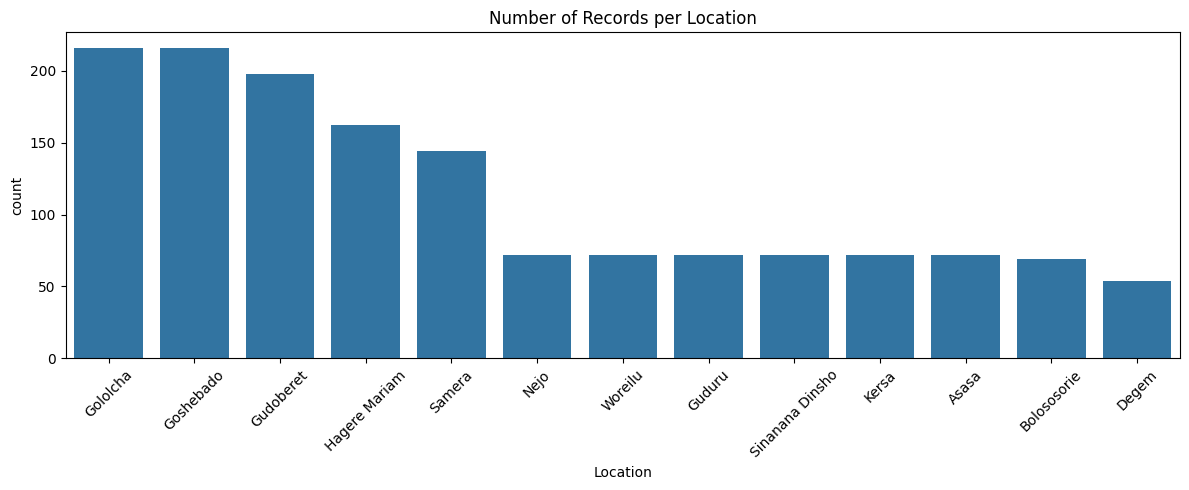

In [55]:
# 4. Countplot  → whether your data is balanced across the 13 locations
plt.figure(figsize=(12, 5))
sns.countplot(x='Location', data=df, order=df['Location'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Number of Records per Location')
plt.tight_layout()
plt.show()

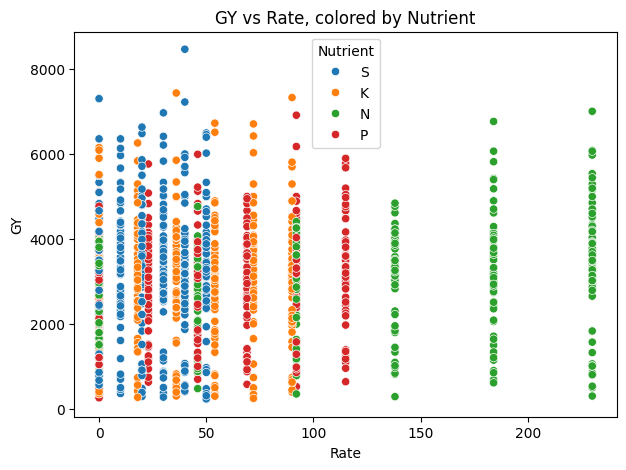

In [56]:
# 5. Scatter plot → whether higher nutrient rate is associated with higher yield
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Rate', y='GY', hue='Nutrient', data=df)
plt.title('GY vs Rate, colored by Nutrient')
plt.show()


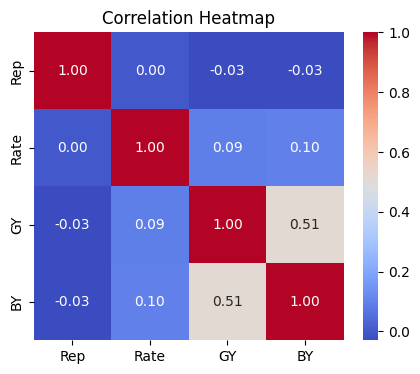

In [57]:
# 6. Correlation heatmap → strength of linear relationship between GY, BY, and Rate
plt.figure(figsize=(5, 4))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [58]:
# 3. Define features / target
TARGET = "GY"  # change to "BY" to predict biomass yield instead

categorical_features = ["Nutrient", "Location", "Agro_Ecological_Zone", "SOIL_TYPE"]
numeric_features = ["Rep", "Rate"]

X = df[categorical_features + numeric_features]

# Force target to numeric here too (belt-and-braces, in case this cell
# gets re-run on its own after the df above was reloaded/edited elsewhere)
y = pd.to_numeric(df[TARGET], errors="coerce")
mask = y.notna()
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [59]:
# 5. Build & train models

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="passthrough",  # keeps Rep, Rate as-is
)
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
    ),
}

results = {}

y_train = pd.to_numeric(y_train, errors="coerce")
y_test = pd.to_numeric(y_test, errors="coerce")
train_mask = y_train.notna()
test_mask = y_test.notna()
X_train, y_train = X_train[train_mask], y_train[train_mask]
X_test, y_test = X_test[test_mask], y_test[test_mask]

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring="r2")

    results[name] = {
        "pipeline": pipe,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "CV_R2_mean": cv_scores.mean(),
        "CV_R2_std": cv_scores.std(),
    }

    print(f"\n--- {name} ---")
    print(f"Test MAE : {mae:.2f}")
    print(f"Test RMSE: {rmse:.2f}")
    print(f"Test R2  : {r2:.3f}")
    print(f"5-fold CV R2: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")



--- Random Forest ---
Test MAE : 767.69
Test RMSE: 1044.39
Test R2  : 0.347
5-fold CV R2: -0.152 (+/- 0.359)

--- Gradient Boosting ---
Test MAE : 636.82
Test RMSE: 836.04
Test R2  : 0.582
5-fold CV R2: -0.155 (+/- 0.355)


In [60]:
# 6. Feature importance (from Random Forest)
# ---------------------------------------------------------------
best_name = max(results, key=lambda k: results[k]["R2"])
best_pipe = results[best_name]["pipeline"]
print(f"\nBest model on test set: {best_name}")

ohe = best_pipe.named_steps["preprocess"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([cat_names, numeric_features])

model_step = best_pipe.named_steps["model"]
if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
    imp_df = pd.DataFrame(
        {"feature": all_feature_names, "importance": importances}
    ).sort_values("importance", ascending=False)
    print("\nTop 10 most important features:")
    print(imp_df.head(10).to_string(index=False))




Best model on test set: Gradient Boosting

Top 10 most important features:
                 feature  importance
Agro_Ecological_Zone_SH3    0.433344
    Location_Bolososorie    0.098681
                    Rate    0.065487
      Location_Gudoberet    0.057322
          Location_Kersa    0.055802
      Location_Goshebado    0.050726
              Nutrient_N    0.033709
Location_Sinanana Dinsho    0.033358
     SOIL_TYPE_Cambisols    0.030062
              Nutrient_S    0.029600


In [61]:
import joblib

# Get the name of the best performing model again
best_name = max(results, key=lambda k: results[k]["R2"])

# Grab your best trained pipeline (which includes preprocessing + model)
best_pipeline = results[best_name]["pipeline"]

# Save it to disk
joblib.dump(best_pipeline, "barley_model_pipeline.pkl")
print("Model saved successfully as barley_model_pipeline.pkl!")

Model saved successfully as barley_model_pipeline.pkl!


In [ ]:
from google.colab import files

files.download("barley_model_pipeline.pkl")
# replace with your actual second filename

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("barley_model_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>